# IPL Auction Price Analysis: Descriptive Statistics

This notebook provides exploratory analysis of IPL auction prices and player performance data (2008-2025).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/analysis/auction_inflation_adjusted.csv')
print(f"Loaded {len(df)} records")
df.head()

Loaded 1948 records


,year,player_name,team_x,base_price_lakh,final_price_lakh,role,nationality,status,source,matches_played,...,five_wickets,best_figures,catches,run_outs,stumpings,inflation_factor,price_2024_lakh,base_price_2024_lakh,price_2024_cr,price_nominal_cr
0,2008,MS Dhoni,CSK,NaN,950.0,Wicket-Keeper,Indian,SOLD,manual_2008,14.0,...,0.0,NaN,6.0,4.0,0.0,2.77628,2637.466307,NaN,26.374663,9.50
1,2008,Andrew Symonds,DCH,NaN,650.0,All-Rounder,Overseas,SOLD,manual_2008,3.0,...,0.0,0/24,3.0,0.0,0.0,2.77628,1804.582210,NaN,18.045822,6.50
2,2008,Sanath Jayasuriya,MI,NaN,575.0,All-Rounder,Overseas,SOLD,manual_2008,14.0,...,0.0,3/14,2.0,3.0,0.0,2.77628,1596.361186,NaN,15.963612,5.75
3,2008,Ishant Sharma,KKR,NaN,550.0,Bowler,Indian,SOLD,manual_2008,5.0,...,0.0,1/13,2.0,0.0,0.0,2.77628,1526.954178,NaN,15.269542,5.50
4,2008,Mahela Jayawardene,DC,NaN,525.0,Batsman,Overseas,SOLD,manual_2008,NaN,...,NaN,NaN,NaN,NaN,NaN,2.77628,1457.547170,NaN,14.575472,5.25


## 1. Price Trends Over Time

/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/755841889.py:31: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/755841889.py:32: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../data/analysis/fig_price_trends.png', dpi=150, bbox_inches='tight')
/Users/soodoku/Documents/GitHub/calibre/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


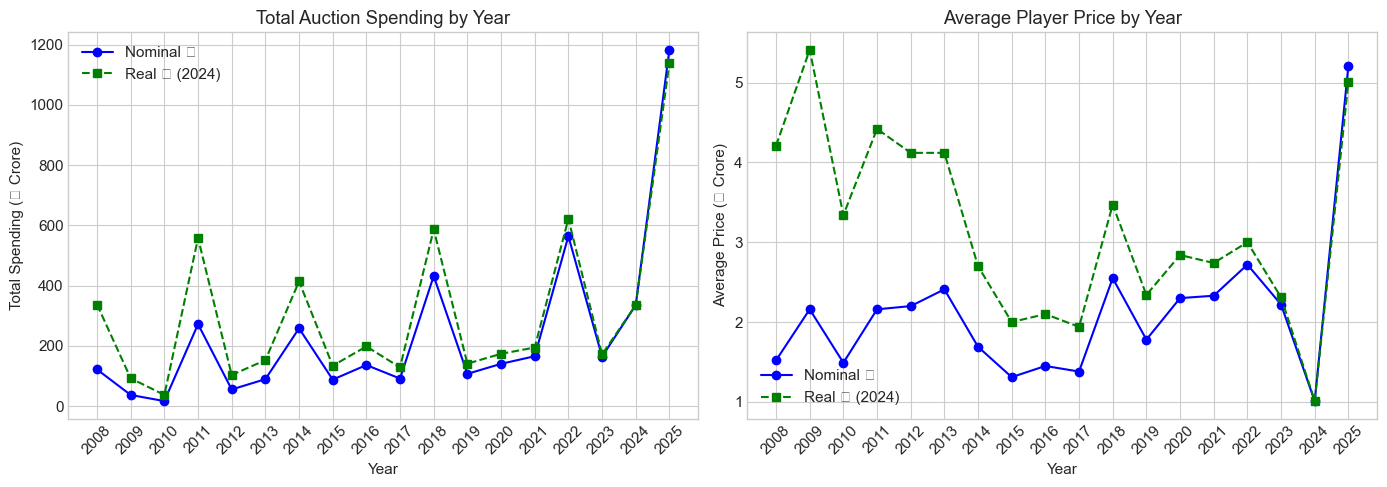

In [2]:
yearly = df.groupby('year').agg({
    'price_nominal_cr': ['sum', 'mean', 'max'],
    'price_2024_cr': ['sum', 'mean', 'max'],
    'player_name': 'count'
}).round(2)
yearly.columns = ['total_nominal', 'avg_nominal', 'max_nominal', 
                  'total_real', 'avg_real', 'max_real', 'n_players']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(yearly.index, yearly['total_nominal'], 'o-', label='Nominal ₹', color='blue')
ax1.plot(yearly.index, yearly['total_real'], 's--', label='Real ₹ (2024)', color='green')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Spending (₹ Crore)')
ax1.set_title('Total Auction Spending by Year')
ax1.legend()
ax1.set_xticks(yearly.index)
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2.plot(yearly.index, yearly['avg_nominal'], 'o-', label='Nominal ₹', color='blue')
ax2.plot(yearly.index, yearly['avg_real'], 's--', label='Real ₹ (2024)', color='green')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Price (₹ Crore)')
ax2.set_title('Average Player Price by Year')
ax2.legend()
ax2.set_xticks(yearly.index)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/analysis/fig_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Price Distribution by Year

/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/1901466504.py:19: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/1901466504.py:20: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../data/analysis/fig_price_distribution.png', dpi=150, bbox_inches='tight')
/Users/soodoku/Documents/GitHub/calibre/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


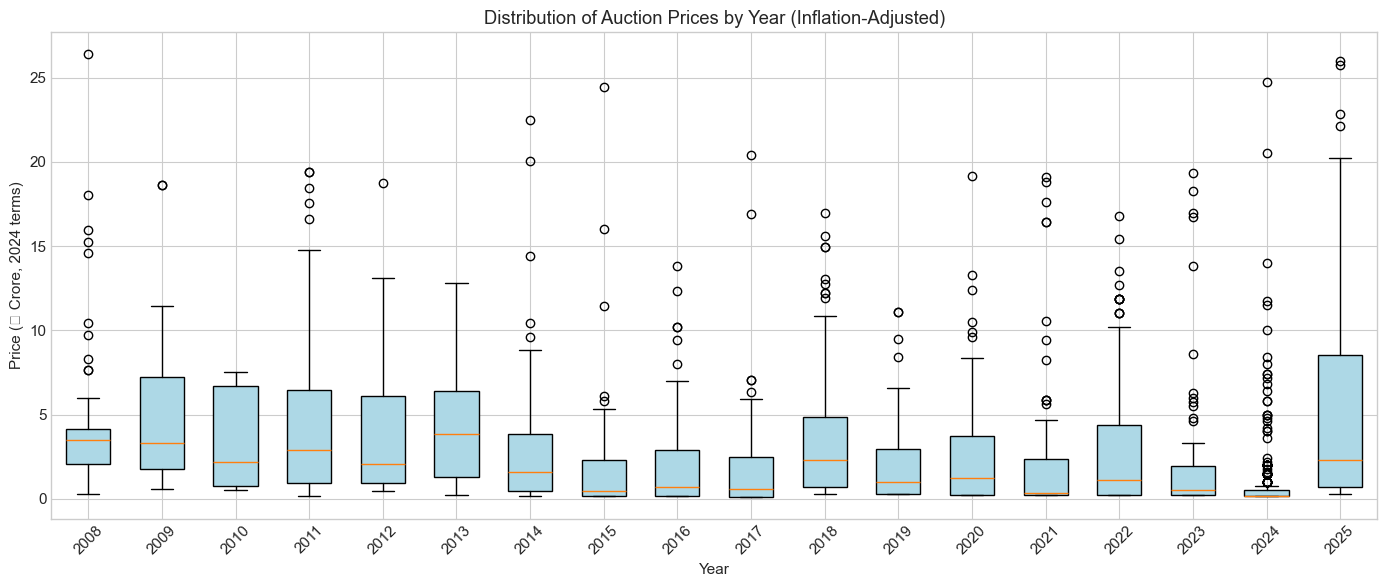

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

df_box = df[df['price_2024_cr'].notna()].copy()
df_box = df_box[df_box['price_2024_cr'] > 0]

years = sorted(df_box['year'].unique())
data = [df_box[df_box['year'] == y]['price_2024_cr'].values for y in years]

bp = ax.boxplot(data, positions=range(len(years)), widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_xlabel('Year')
ax.set_ylabel('Price (₹ Crore, 2024 terms)')
ax.set_title('Distribution of Auction Prices by Year (Inflation-Adjusted)')

plt.tight_layout()
plt.savefig('../data/analysis/fig_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Top 10 Deals by Year

/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/2549228716.py:19: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/2549228716.py:20: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../data/analysis/fig_top_deals.png', dpi=150, bbox_inches='tight')


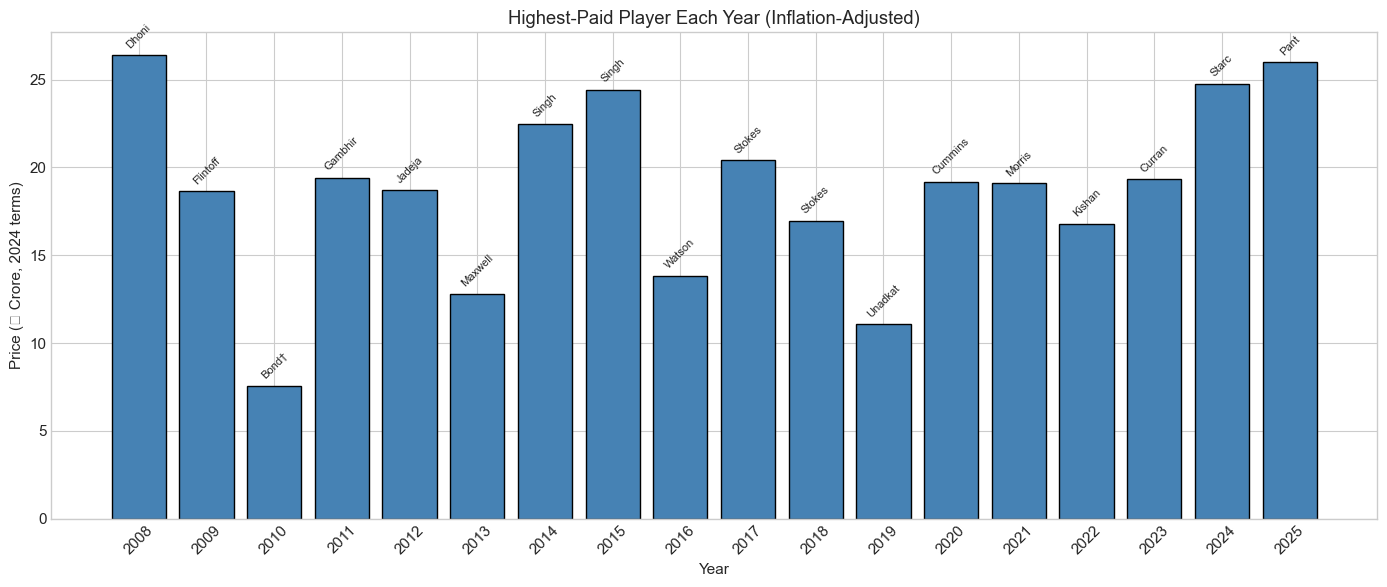


Top deal each year:
 year             player_name  team_x  price_nominal_cr  price_2024_cr
 2008                MS Dhoni     CSK             9.500      26.374663
 2009         Andrew Flintoff Unknown             7.440      18.645255
 2010 New Zealand Shane Bond†     KKR             3.375       7.557065
 2011          Gautam Gambhir     KKR             9.450      19.389442
 2012         Ravindra Jadeja     CSK            10.000      18.727273
 2013           Glenn Maxwell      MI             7.500      12.810945
 2014            Yuvraj Singh     RCB            14.000      22.461059
 2015            Yuvraj Singh      DC            16.000      24.432913
 2016            Shane Watson     RCB             9.500      13.820621
 2017         Benjamin Stokes     RPS            14.500      20.403005
 2018         Benjamin Stokes      RR            12.500      16.974291
 2019          Jaydev Unadkat      RR             8.400      11.063939
 2020             Pat Cummins     KKR            15.500 

In [4]:
top_by_year = df.loc[df.groupby('year')['price_2024_cr'].idxmax()]
top_by_year = top_by_year.sort_values('year')

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(top_by_year['year'], top_by_year['price_2024_cr'], color='steelblue', edgecolor='black')

for bar, (_, row) in zip(bars, top_by_year.iterrows()):
    name = row['player_name'].split()[-1] if pd.notna(row['player_name']) else ''
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            name, ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xlabel('Year')
ax.set_ylabel('Price (₹ Crore, 2024 terms)')
ax.set_title('Highest-Paid Player Each Year (Inflation-Adjusted)')
ax.set_xticks(top_by_year['year'])
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/analysis/fig_top_deals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop deal each year:")
print(top_by_year[['year', 'player_name', 'team_x', 'price_nominal_cr', 'price_2024_cr']].to_string(index=False))

## 4. Price by Player Role

Price statistics by role:
               mean  median    max  count
role                                     
Batsman        3.30    1.39  25.99    341
All-Rounder    2.85    0.75  22.86    590
Bowler         2.54    0.96  24.75    616
Wicket-Keeper  2.33    0.50  26.37    150


/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/1881821481.py:19: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/1881821481.py:20: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../data/analysis/fig_price_by_role.png', dpi=150, bbox_inches='tight')
/Users/soodoku/Documents/GitHub/calibre/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


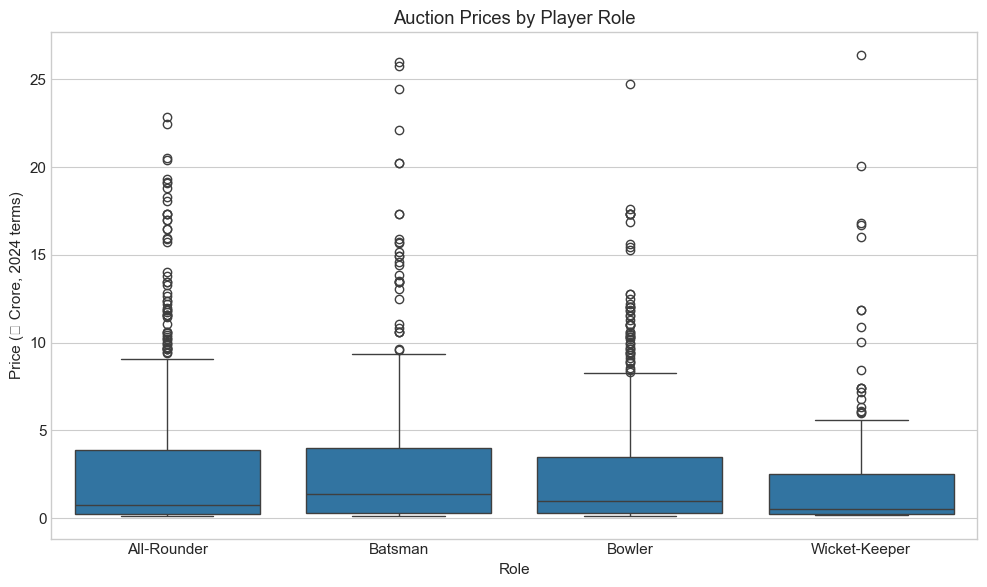

In [5]:
role_stats = df.groupby('role').agg({
    'price_2024_cr': ['mean', 'median', 'max', 'count']
}).round(2)
role_stats.columns = ['mean', 'median', 'max', 'count']
role_stats = role_stats.sort_values('mean', ascending=False)
print("Price statistics by role:")
print(role_stats)

fig, ax = plt.subplots(figsize=(10, 6))

roles_to_plot = ['All-Rounder', 'Batsman', 'Bowler', 'Wicket-Keeper']
df_roles = df[df['role'].isin(roles_to_plot) & df['price_2024_cr'].notna()]

sns.boxplot(data=df_roles, x='role', y='price_2024_cr', order=roles_to_plot, ax=ax)
ax.set_xlabel('Role')
ax.set_ylabel('Price (₹ Crore, 2024 terms)')
ax.set_title('Auction Prices by Player Role')

plt.tight_layout()
plt.savefig('../data/analysis/fig_price_by_role.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Indian vs Overseas Premium

/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/34053787.py:23: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/34053787.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../data/analysis/fig_nationality_premium.png', dpi=150, bbox_inches='tight')
/Users/soodoku/Documents/GitHub/calibre/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


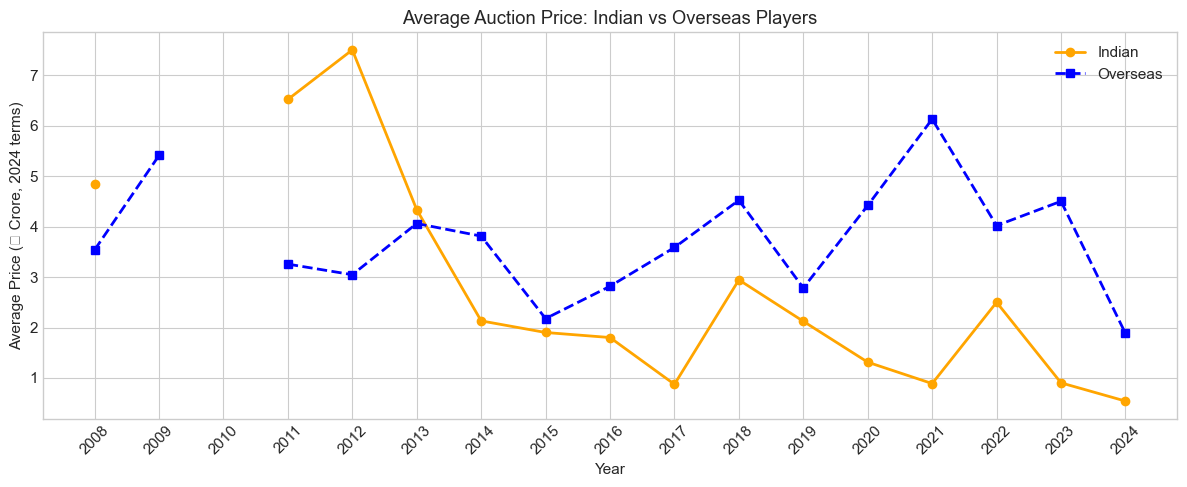


Overall nationality comparison:
             mean  median  count
nationality                     
Indian       2.07    0.33    979
Overseas     3.51    1.87    659
Unknown      3.34    2.22     11


In [6]:
nat_yearly = df.groupby(['year', 'nationality']).agg({
    'price_2024_cr': 'mean',
    'player_name': 'count'
}).reset_index()
nat_yearly.columns = ['year', 'nationality', 'avg_price', 'n_players']

nat_pivot = nat_yearly.pivot(index='year', columns='nationality', values='avg_price')

fig, ax = plt.subplots(figsize=(12, 5))

if 'Indian' in nat_pivot.columns:
    ax.plot(nat_pivot.index, nat_pivot['Indian'], 'o-', label='Indian', color='orange', linewidth=2)
if 'Overseas' in nat_pivot.columns:
    ax.plot(nat_pivot.index, nat_pivot['Overseas'], 's--', label='Overseas', color='blue', linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Average Price (₹ Crore, 2024 terms)')
ax.set_title('Average Auction Price: Indian vs Overseas Players')
ax.legend()
ax.set_xticks(nat_pivot.index)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/analysis/fig_nationality_premium.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOverall nationality comparison:")
print(df.groupby('nationality')['price_2024_cr'].agg(['mean', 'median', 'count']).round(2))

## 6. Performance vs Price Scatterplots

/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/2105956581.py:30: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_41865/2105956581.py:31: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig('../data/analysis/fig_performance_vs_price.png', dpi=150, bbox_inches='tight')
/Users/soodoku/Documents/GitHub/calibre/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


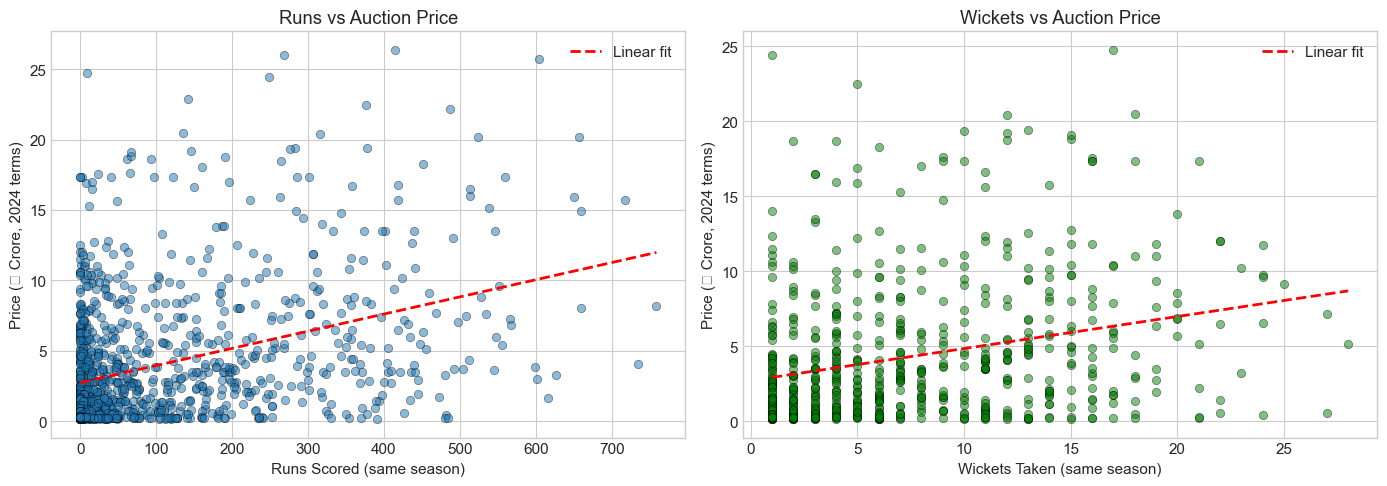


Correlation (runs vs price): 0.382
Correlation (wickets vs price): 0.276


In [7]:
df_perf = df[df['runs'].notna() & df['price_2024_cr'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(df_perf['runs'], df_perf['price_2024_cr'], alpha=0.5, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Runs Scored (same season)')
ax1.set_ylabel('Price (₹ Crore, 2024 terms)')
ax1.set_title('Runs vs Auction Price')

z = np.polyfit(df_perf['runs'], df_perf['price_2024_cr'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_perf['runs'].min(), df_perf['runs'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Linear fit')
ax1.legend()

ax2 = axes[1]
df_bowl = df_perf[df_perf['wickets'] > 0]
ax2.scatter(df_bowl['wickets'], df_bowl['price_2024_cr'], alpha=0.5, edgecolors='black', linewidth=0.5, color='green')
ax2.set_xlabel('Wickets Taken (same season)')
ax2.set_ylabel('Price (₹ Crore, 2024 terms)')
ax2.set_title('Wickets vs Auction Price')

z2 = np.polyfit(df_bowl['wickets'], df_bowl['price_2024_cr'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_bowl['wickets'].min(), df_bowl['wickets'].max(), 100)
ax2.plot(x_line2, p2(x_line2), 'r--', linewidth=2, label=f'Linear fit')
ax2.legend()

plt.tight_layout()
plt.savefig('../data/analysis/fig_performance_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

corr_runs = df_perf['runs'].corr(df_perf['price_2024_cr'])
corr_wickets = df_bowl['wickets'].corr(df_bowl['price_2024_cr'])
print(f"\nCorrelation (runs vs price): {corr_runs:.3f}")
print(f"Correlation (wickets vs price): {corr_wickets:.3f}")

## 7. Top All-Time Deals (Inflation-Adjusted)

In [8]:
top_20 = df.nlargest(20, 'price_2024_cr')[[
    'year', 'player_name', 'team_x', 'role', 'nationality',
    'price_nominal_cr', 'price_2024_cr'
]].copy()
top_20['rank'] = range(1, 21)
top_20 = top_20[['rank', 'year', 'player_name', 'team_x', 'role', 'price_nominal_cr', 'price_2024_cr']]

print("Top 20 All-Time IPL Deals (Inflation-Adjusted to 2024 ₹):")
print(top_20.to_string(index=False))

Top 20 All-Time IPL Deals (Inflation-Adjusted to 2024 ₹):
 rank  year        player_name team_x          role  price_nominal_cr  price_2024_cr
    1  2008           MS Dhoni    CSK Wicket-Keeper              9.50      26.374663
    2  2025       Rishabh Pant    LSG       Batsman             27.00      25.990654
    3  2025       Shreyas Iyer   PBKS       Batsman             26.75      25.750000
    4  2024     Mitchell Starc    KKR        Bowler             24.75      24.750000
    5  2015       Yuvraj Singh     DC       Batsman             16.00      24.432913
    6  2025     Venkatesh Iyer    KKR   All-Rounder             23.75      22.862150
    7  2014       Yuvraj Singh    RCB   All-Rounder             14.00      22.461059
    8  2025   Heinrich Klaasen    SRH       Batsman             23.00      22.140187
    9  2024        Pat Cummins     SH   All-Rounder             20.50      20.500000
   10  2017    Benjamin Stokes    RPS   All-Rounder             14.50      20.403005
   11  

## Summary Statistics

In [9]:
print("=== Dataset Summary ===")
print(f"Total auction records: {len(df)}")
print(f"Years covered: {df['year'].min()} - {df['year'].max()}")
print(f"Unique players: {df['player_name'].nunique()}")
print(f"\nRecords with performance data: {df['runs'].notna().sum()} ({df['runs'].notna().mean()*100:.1f}%)")
print(f"\nTotal nominal spending: ₹{df['price_nominal_cr'].sum():.0f} Cr")
print(f"Total real spending (2024 ₹): ₹{df['price_2024_cr'].sum():.0f} Cr")
print(f"\nMean price (nominal): ₹{df['price_nominal_cr'].mean():.2f} Cr")
print(f"Mean price (2024 ₹): ₹{df['price_2024_cr'].mean():.2f} Cr")
print(f"Median price (2024 ₹): ₹{df['price_2024_cr'].median():.2f} Cr")

=== Dataset Summary ===
Total auction records: 1948
Years covered: 2008 - 2025
Unique players: 1001

Records with performance data: 1220 (62.6%)

Total nominal spending: ₹4252 Cr
Total real spending (2024 ₹): ₹5512 Cr

Mean price (nominal): ₹2.27 Cr
Mean price (2024 ₹): ₹2.94 Cr
Median price (2024 ₹): ₹1.06 Cr
